In [3]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.columns = df.columns.str.strip()

print(f"Dataset loaded successfully!")
print(f"Employees: {len(df)}")
print(f"Variables: {len(df.columns)}")
df.head()

Dataset loaded successfully!
Employees: 1470
Variables: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Key Findings Summary

| Metric | Value |
|--------|-------|
| Total Employees | 1,470 |
| Employees Who Left | 237 |
| Turnover Rate | 16.1% |


| Avg Income Stayed | $6,833 |
| Avg Income Left | $4,787 |
| Avg Age Stayed | 37.6 years|
| Avg Age Left | 33.6 years |
| Annual Cost of Attrition | R155,352,427 |

**Key Insight:** Employees who left earned $2,046 less per month than those who stayed.Low compensation combined with overtime are the strongest predictors of attrition.

In [5]:
left = df[df['Attrition']== 'Yes']
stayed = df[df['Attrition'] == 'No']
turnover_rate = len(left) / len(df) * 100
print(f"Employees Who left: {len(left)}")
print(f"Employees Who stayed: {len(stayed)}")
print(f"Turnover Rate: {turnover_rate:.1f}%")
print("\nAverages by Attrition:")
df.groupby('Attrition')[['Age','MonthlyIncome','YearsAtCompany']].mean().round(1)


Employees Who left: 237
Employees Who stayed: 1233
Turnover Rate: 16.1%

Averages by Attrition:


,Age,MonthlyIncome,YearsAtCompany
Attrition,,,
No,37.6,6832.7,7.4
Yes,33.6,4787.1,5.1


## Business Cost Analysis
The financial impact of attrition is calculated using the industry standards replacement cost of 50% of annual salary per departing employee as  confirmed by Gallup research.

In [6]:
avg_salary = df['MonthlyIncome'].mean() * 12
replacement_cost = avg_salary * 0.5
zar_rate = 16.80
total_cost_zar = len(left) * replacement_cost * zar_rate
print(f"Average Annual Salary: ${avg_salary:,.0f}")
print(f"Replacement Cost Per Person: ${replacement_cost:,.0f}")
print(f"Total Annual Cost (ZAR): R{total_cost_zar:,.0f}")



Average Annual Salary: $78,035
Replacement Cost Per Person: $39,018
Total Annual Cost (ZAR): R155,352,427


## Visual Analysis
The following charts explore attrition patterns across income, age, overtime, job satisfaction, department, and key variable correlations.

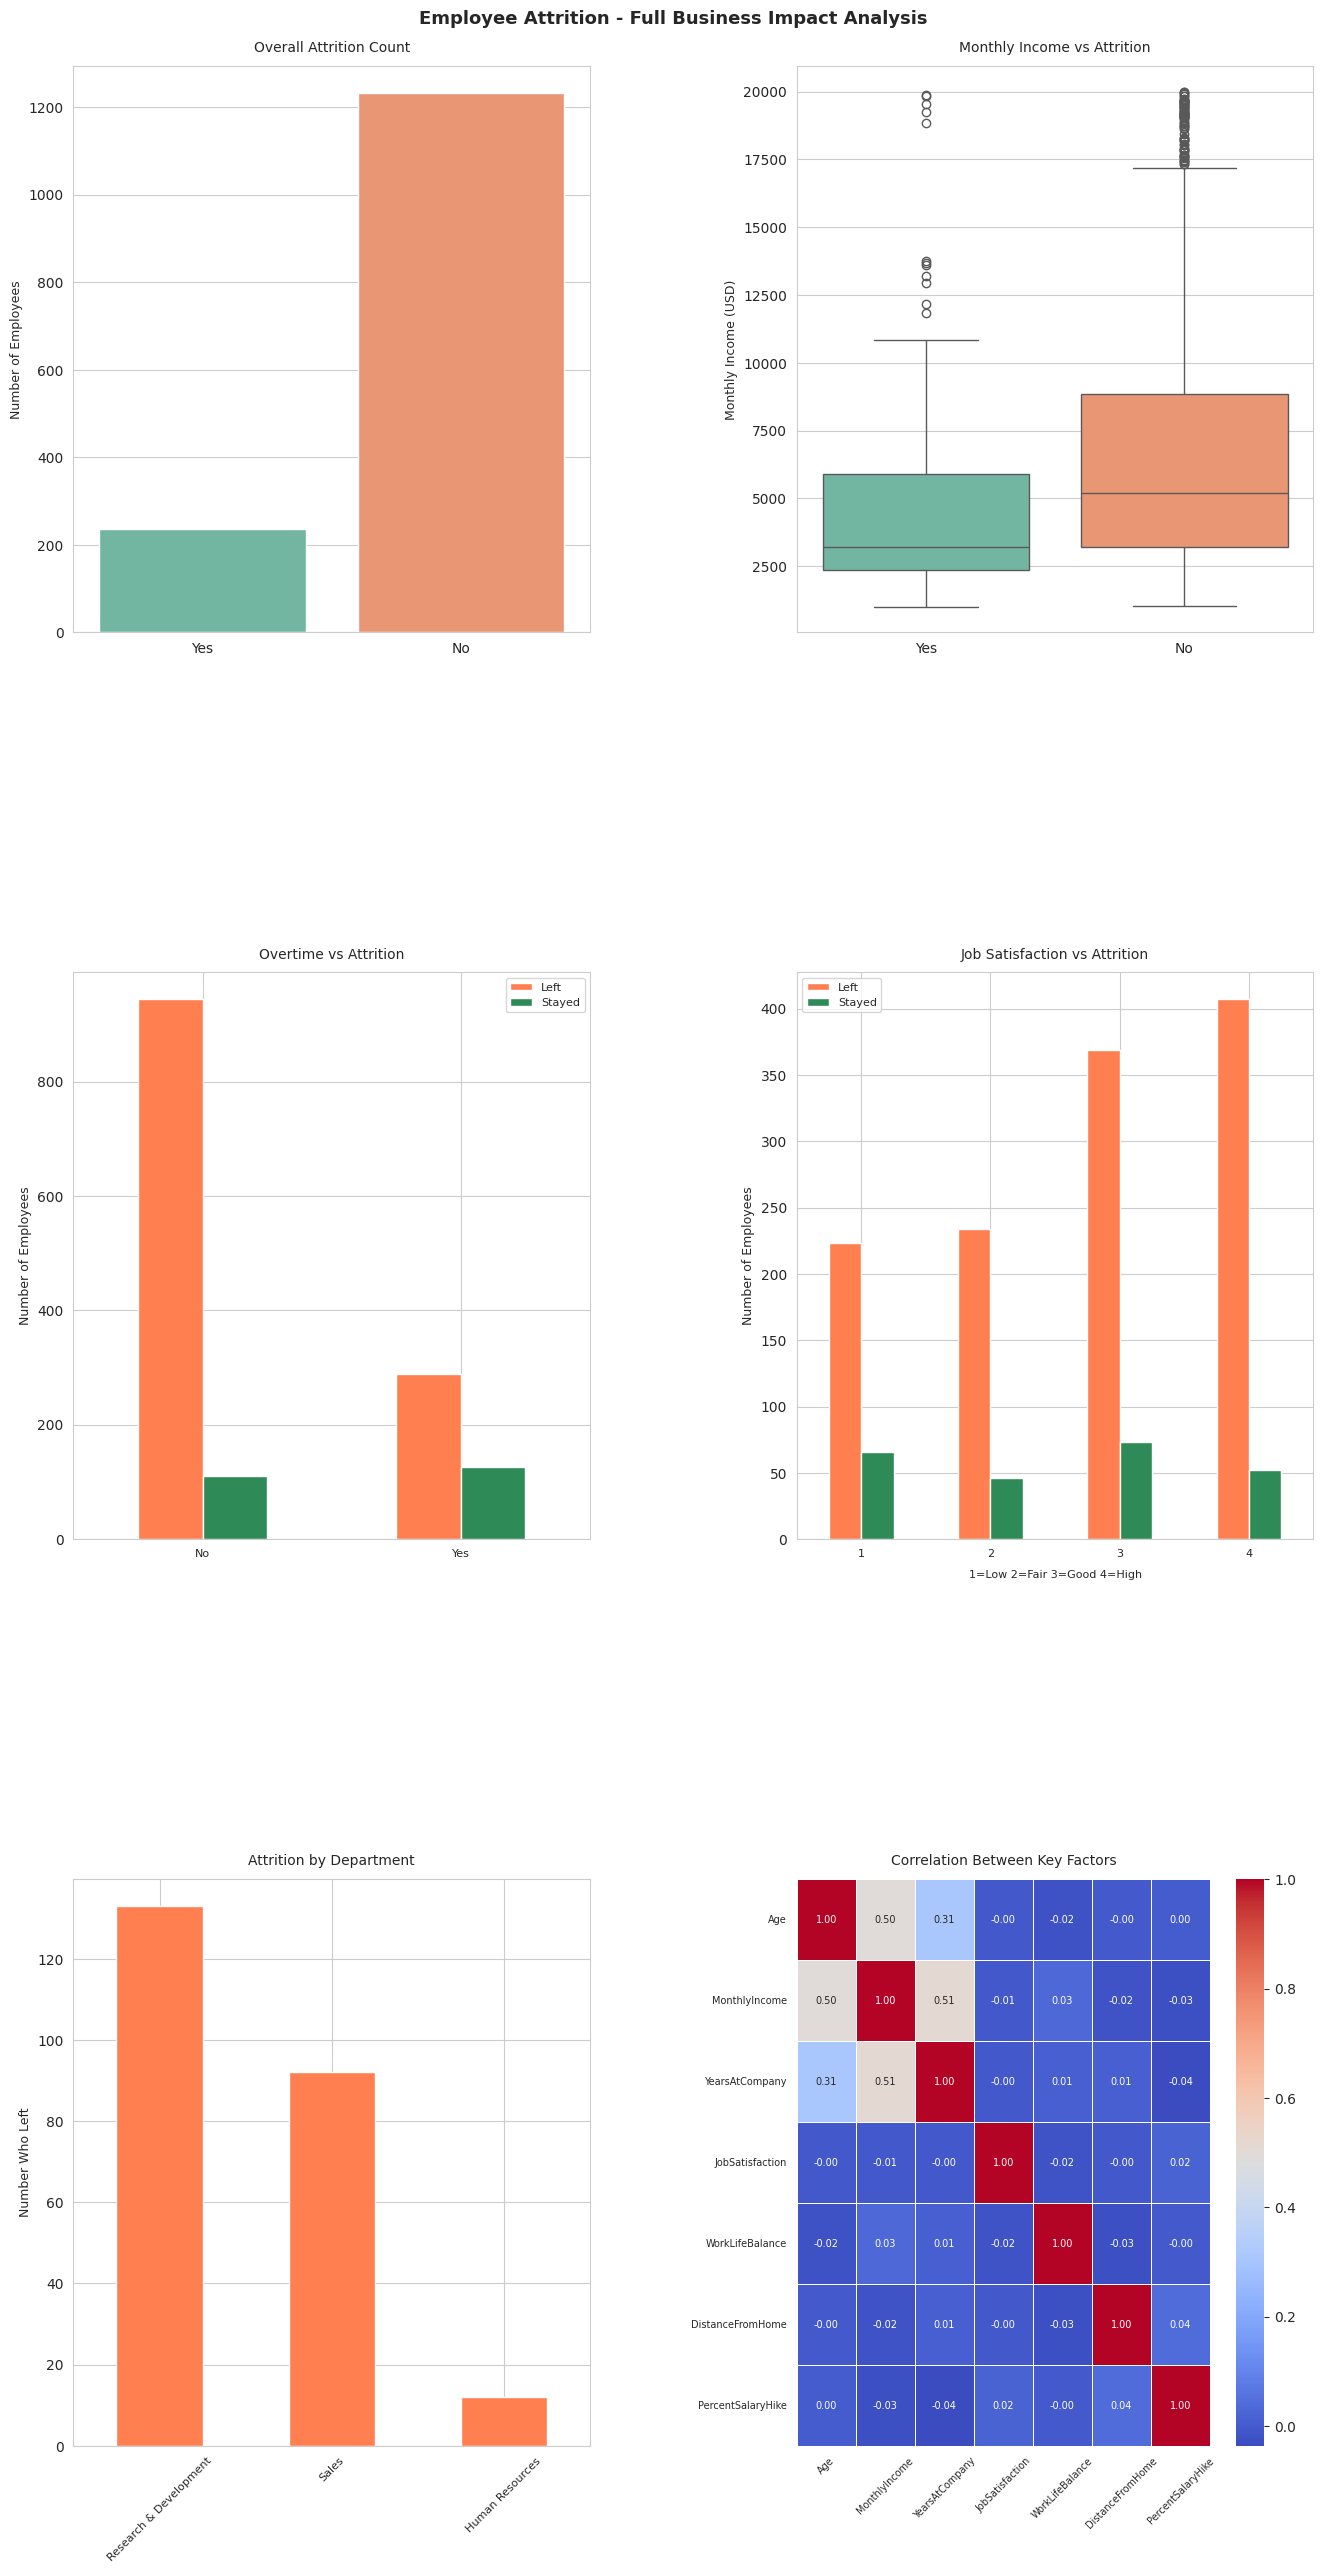

In [7]:
sns.set_style("whitegrid")
fig = plt.figure(figsize=(16, 28))
fig.suptitle('Employee Attrition - Full Business Impact Analysis',
             fontsize=13, fontweight='bold', y=0.98)

ax1 = fig.add_subplot(3, 2, 1)
sns.countplot(data=df, x='Attrition', hue='Attrition',
              palette='Set2', legend=False, ax=ax1)
ax1.set_title('Overall Attrition Count', fontsize=10, pad=10)
ax1.set_xlabel('')
ax1.set_ylabel('Number of Employees', fontsize=9)

ax2 = fig.add_subplot(3, 2, 2)
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
            palette='Set2', legend=False, ax=ax2)
ax2.set_title('Monthly Income vs Attrition', fontsize=10, pad=10)
ax2.set_xlabel('')
ax2.set_ylabel('Monthly Income (USD)', fontsize=9)

ax3 = fig.add_subplot(3, 2, 3)
overtime_plot = df.groupby('OverTime')['Attrition'].value_counts().unstack()
overtime_plot.plot(kind='bar', ax=ax3, color=['coral', 'seagreen'])
ax3.set_title('Overtime vs Attrition', fontsize=10, pad=10)
ax3.set_xlabel('')
ax3.set_ylabel('Number of Employees', fontsize=9)
ax3.tick_params(axis='x', rotation=0, labelsize=8)
ax3.legend(['Left', 'Stayed'], fontsize=8)

ax4 = fig.add_subplot(3, 2, 4)
sat_plot = df.groupby(['JobSatisfaction','Attrition']).size().unstack()
sat_plot.plot(kind='bar', ax=ax4, color=['coral', 'seagreen'])
ax4.set_title('Job Satisfaction vs Attrition', fontsize=10, pad=10)
ax4.set_xlabel('1=Low 2=Fair 3=Good 4=High', fontsize=8, labelpad=8)
ax4.set_ylabel('Number of Employees', fontsize=9)
ax4.tick_params(axis='x', rotation=0, labelsize=8)
ax4.legend(['Left', 'Stayed'], fontsize=8)

ax5 = fig.add_subplot(3, 2, 5)
dept = df[df['Attrition'] == 'Yes']['Department'].value_counts()
dept.plot(kind='bar', color='coral', ax=ax5)
ax5.set_title('Attrition by Department', fontsize=10, pad=10)
ax5.set_xlabel('')
ax5.set_ylabel('Number Who Left', fontsize=9)
ax5.tick_params(axis='x', rotation=45, labelsize=8)

ax6 = fig.add_subplot(3, 2, 6)
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                'JobSatisfaction', 'WorkLifeBalance',
                'DistanceFromHome', 'PercentSalaryHike']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax6, linewidths=0.5, annot_kws={"size": 7})
ax6.set_title('Correlation Between Key Factors', fontsize=10, pad=10)
ax6.tick_params(axis='x', rotation=45, labelsize=7)
ax6.tick_params(axis='y', rotation=0, labelsize=7)

plt.subplots_adjust(hspace=0.6, wspace=0.4, top=0.96)
plt.savefig('full_attrition_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



## Recommendations

Based on the analysis, the following actions are recommended
to reduce the 16.1% turnover rate and save R155M annually:

1. Review compensation for below-median earners urgently
2. Audit overtime practices in Research and Development
3. Introduce stay interviews for employees under 35
4. Implement early warning system for low satisfaction scores
5. Focus retention efforts on Research and Development
   and Sales departments


## Conclusion

This analysis demonstrates that employee attrition at this
organisation is strongly driven by compensation gaps and
overtime demands. Addressing these two factors alone could
significantly reduce the estimated R155M annual cost of turnover. People Analytics provides the evidence base for
targeted, cost-effective HR intervention.


**Author:** Nivasha Govender

**Tools:** Python, pandas, matplotlib, seaborn

**Dataset:** IBM HR Analytics Employee Attrition



## Data Verification
The following cell verifies all key metrics cited in this analysis to ensure accuracy and consistency.

In [8]:
print(f"Left: {len(left)}")
print(f"Stayed: {len(stayed)}")
print(f"Turnover: {len(left)/len(df)*100:.1f}%")
avg_salary = df['MonthlyIncome'].mean() * 12
replacement_cost = avg_salary * 0.5
zar_rate = 16.80
total_zar = len(left) * replacement_cost * zar_rate
print(f"ZAR Cost: R{total_zar:,.0f}")
print(f"\nAvg Income Left: ${df[df['Attrition']=='Yes']['MonthlyIncome'].mean():,.0f}")
print(f"Avg Income Stayed: ${df[df['Attrition']=='No']['MonthlyIncome'].mean():,.0f}")

Left: 237
Stayed: 1233
Turnover: 16.1%
ZAR Cost: R155,352,427

Avg Income Left: $4,787
Avg Income Stayed: $6,833
